In [4]:
import numpy as np
import scipy
import scipy.sparse
import scipy.sparse.linalg
import scipy.stats
import networkx as nx

import matplotlib
import matplotlib.cm
import matplotlib.pyplot as plt

import cnetwork
from cnetwork import p_lithostatic, T_geothermal, MagmaChamber, GlobalSystem, GlobalSystemThreshold
import percolation_network

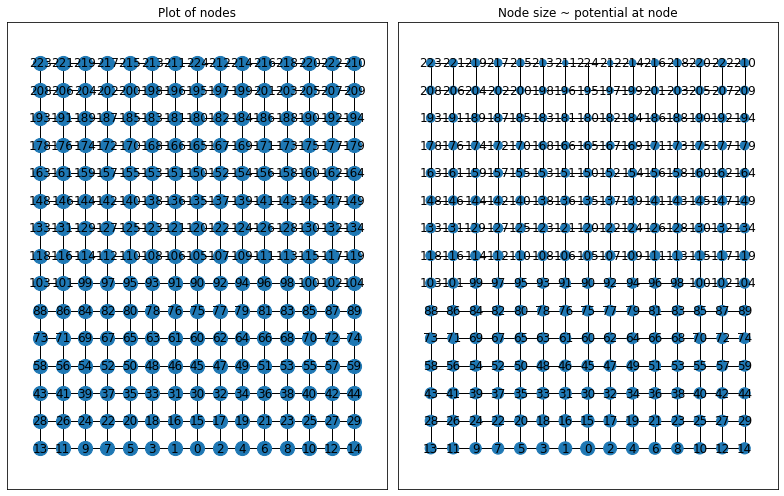

In [76]:
N_x = 15
N_z = 15
x_scale = 40e3
z_scale = 40e3
max_edge_dist = z_scale / (N_z-1) * 1.001
RG = percolation_network.RandomGraph(
  percolation_network.make_2D_grid_network(N_x, N_z, x_scale=x_scale, z_scale=z_scale,
                         R=500,
                         add_source_sink=False), max_edge_dist)

plt.figure(figsize=(11,7))

plt.subplot(1,2,1)
RG.draw_network()
plt.title("Plot of nodes")

plt.subplot(1,2,2)
v = RG.compute_st_potentials()
# plt.plot(v.squeeze())
length_scale = 1.0
nx.draw_networkx(RG.G, pos = {i:(n.x / length_scale, n.z / length_scale,)
                for (i, n) in enumerate(RG.node_list)}, node_size=(v - v.min())/30)
plt.title("Node size ~ potential at node")
plt.tight_layout()

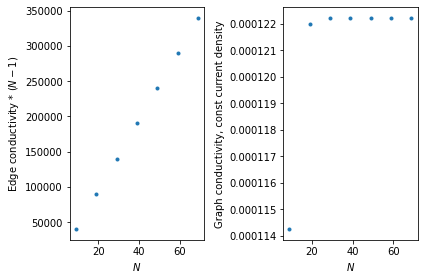

In [77]:
''' Lateral expansion '''
N_range = np.arange(9, 70, 10)
# N_range = np.array([23])
gc_range = np.zeros((len(N_range),))
ec_range = np.zeros((len(N_range),))

z_scale = 40e3

for i, N in enumerate(N_range):
  N_x = N
  N_z = 9
  x_scale = z_scale * (N_x-1) / (N_z-1)

  max_edge_dist = z_scale / (N_z-1) * 1.001
  RG = percolation_network.RandomGraph(
    percolation_network.make_2D_grid_network(N_x, N_z,
      x_scale=x_scale, z_scale=z_scale, R=500,
                          add_source_sink=False), max_edge_dist)
  gc_range[i] = RG.graph_conductivity()
  ec_range[i] = RG.edge_conductivity_list().max()

plt.subplot(1,2,1)
plt.plot(N_range, (N_range-1) / ec_range, '.')
plt.xlabel("$N$")
plt.ylabel("Edge conductivity * $(N-1)$")

plt.subplot(1,2,2)
plt.plot(N_range, gc_range, '.')
# plt.plot(N_range, gc_range / (N_range-1)**(1), '.')
plt.xlabel("$N$")
plt.ylabel("Graph conductivity, const current density")

plt.tight_layout()

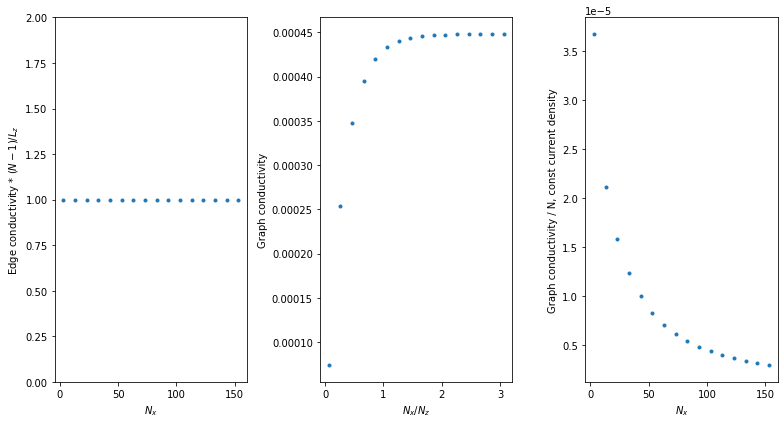

In [78]:
''' Fixed N_z and spacing; varying N_x '''
N_x_range = np.arange(3, 160, 10)
gc_range = np.zeros((len(N_x_range),))
ec_range = np.zeros((len(N_x_range),))

z_scale = 40e3

N_z = 50
for i, N_x in enumerate(N_x_range):
  # Set x-spacing equal to z-spacing
  x_scale = z_scale * (N_x-1) / (N_z-1)

  # Set grid graph with lattice edges
  max_edge_dist = z_scale / (N_z-1) * 1.001
  RG = percolation_network.RandomGraph(
    percolation_network.make_2D_grid_network(N_x, N_z,
      x_scale=x_scale, z_scale=z_scale, R=500,
                          add_source_sink=False), max_edge_dist)
  gc_range[i] = RG.graph_conductivity()
  ec_range[i] = RG.edge_conductivity_list().max()

plt.figure(figsize=(11,6))

plt.subplot(1,3,1)
plt.plot(N_x_range, (N_z - 1) / ec_range / z_scale, '.')
plt.ylim(0, 2)
plt.xlabel("$N_x$")
plt.ylabel("Edge conductivity * $(N-1) / L_z$")

plt.subplot(1,3,2)
plt.plot(N_x_range / N_z, gc_range, '.')
plt.xlabel("$N_x / N_z$")
plt.ylabel("Graph conductivity")

plt.subplot(1,3,3)
plt.plot(N_x_range, gc_range / (N_x_range-1)**(1), '.')
plt.xlabel("$N_x$")
plt.ylabel("Graph conductivity / N, const current density")

plt.tight_layout()

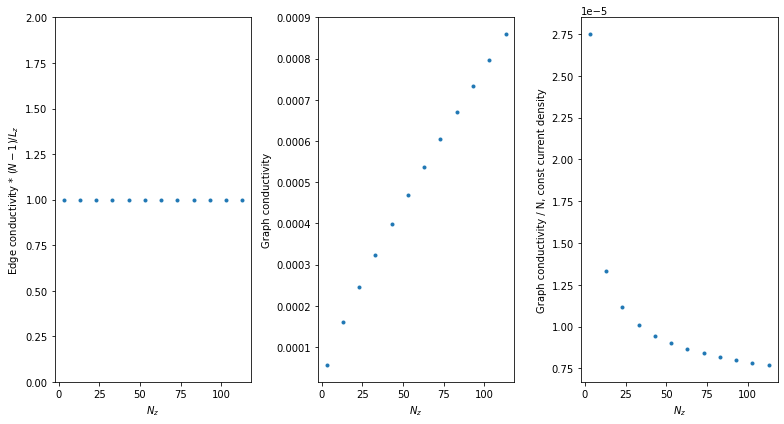

In [79]:
''' Fixed (N_x-1) / (N_z-1), varying N_z '''

# N_range = np.array([*np.arange(3, 15, 2), *np.arange(15, 56, 6)])
N_range = np.arange(3, 120, 10)
gc_range = np.zeros((len(N_range),))
ec_range = np.zeros((len(N_range),))

z_scale = 40e3

for i, N in enumerate(N_range):
  N_z = N
  N_x = 2*N - 1
  x_scale = z_scale * (N_x-1) / (N_z-1)

  # Set grid graph with lattice edges
  max_edge_dist = z_scale / (N_z-1) * 1.01
  RG = percolation_network.RandomGraph(
    percolation_network.make_2D_grid_network(N_x, N_z,
      x_scale=x_scale, z_scale=z_scale, R=500,
                          add_source_sink=False), max_edge_dist)
  gc_range[i] = RG.graph_conductivity()
  ec_range[i] = RG.edge_conductivity_list().max()

plt.figure(figsize=(11,6))

plt.subplot(1,3,1)
plt.plot(N_range, (N_range - 1) / ec_range / z_scale, '.')
plt.ylim(0, 2)
plt.xlabel("$N_z$")
plt.ylabel("Edge conductivity * $(N-1) / L_z$")

plt.subplot(1,3,2)
plt.plot(N_range, gc_range, '.')
plt.xlabel("$N_z$")
plt.ylabel("Graph conductivity")

plt.subplot(1,3,3)
plt.plot(N_range, gc_range / (N_range-1)**(1), '.')
plt.xlabel("$N_z$")
plt.ylabel("Graph conductivity / N, const current density")

plt.tight_layout()

Right: continuous log potential is singular; here regularized by replacing r^2 with r^2 + eps^2. 


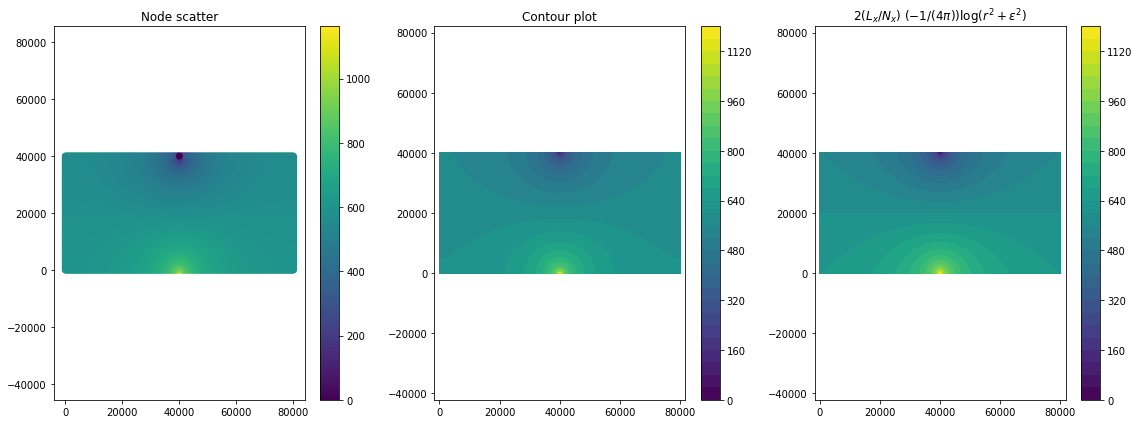

In [97]:
''' Plot graph potentials of last known graph `RG` '''

v = RG.compute_st_potentials()
v -= v.min()

plt.figure(figsize=(16,6))

plt.subplot(1,3,1)
plt.scatter([n.x / length_scale for (i, n) in enumerate(RG.node_list)],
            [n.z / length_scale for (i, n) in enumerate(RG.node_list)],
            c=v)
plt.colorbar()
plt.title("Node scatter")
plt.axis("equal")
# Reconstruct node coordinates as array
coords = np.array([[n.x, n.z] for (i, n) in enumerate(RG.node_list)])
ind = np.lexsort(coords.T)
v_flat = v[ind]
x_flat, z_flat = coords[ind,:].T
mg_x = np.reshape(x_flat, (N_z, N_x))
mg_z = np.reshape(z_flat, (N_z, N_x))
mg_v = np.reshape(v_flat, (N_z, N_x))

plt.subplot(1,3,2)
plt.contourf(mg_x, mg_z, mg_v, levels=30)
plt.colorbar()
plt.title("Contour plot")
plt.axis("equal")

eps = x_scale / N_x * 1e-14
Gs = -1/(4*np.pi) * np.log((mg_x - 0.5*x_scale)**2 + mg_z**2 + eps*eps)
Gt = 1/(4*np.pi) * np.log((mg_x - 0.5*x_scale)**2 + (mg_z-z_scale)**2 + eps*eps)
rs = np.sqrt((mg_x - 0.5*x_scale)**2 + (mg_z)**2)
rt = np.sqrt((mg_x - 0.5*x_scale)**2 + (mg_z-z_scale)**2)

analog_potential = 2 * (x_scale / N_x) * (Gs + Gt)
# dGdy = 1/(2*np.pi) / rs * (mg_z / rs)
plt.subplot(1,3,3)
plt.contourf(mg_x, mg_z, np.clip(analog_potential, -600, 600)+600, levels=30)
# plt.contourf(mg_x, mg_z, dGdy, levels=30)
plt.colorbar()
plt.title(r"$2 (L_x / N_x)~(-1/(4\pi))\log(r^2 + \epsilon^2)$")
plt.axis("equal")

plt.tight_layout()
print("Right: continuous log potential is singular; here regularized by replacing r^2 with r^2 + eps^2. ")

In [49]:
draw_dense_network = False
if draw_dense_network:
  nx.draw_networkx(RG.G, pos = {i:(n.x / length_scale, n.z / length_scale,)
                  for (i, n) in enumerate(RG.node_list)}, node_size=v/100)

In [75]:
gc_range

array([5.50000000e-05, 1.59673807e-04, 2.45226499e-04, 3.23524877e-04,
       3.97533948e-04, 4.68571746e-04, 5.37371324e-04, 6.04394152e-04,
       6.69954863e-04, 7.34280329e-04, 7.97541086e-04, 8.59869511e-04])

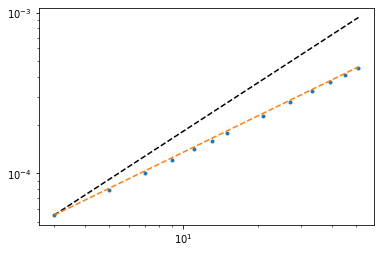

In [46]:
plt.loglog(N_range, gc_range, '.')
plt.loglog(N_range, (N_range/N_range[0])*gc_range[0], 'k--')
plt.loglog(N_range, (N_range/N_range[0])**.75*gc_range[0], '--')


#### Stochastic

2555.266830685947

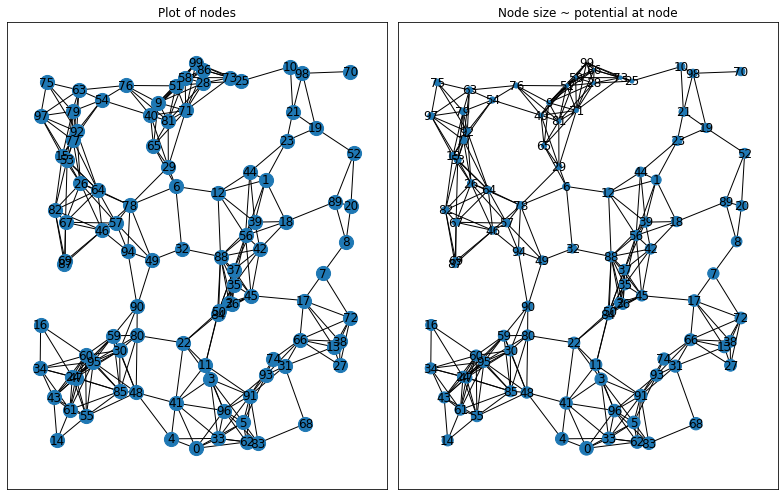

In [26]:
np.random.seed(0)

N = 100
x_scale = 40e3
z_scale = 40e3
# Length scale
sep_scale = np.sqrt(x_scale * z_scale) / (np.sqrt(N)-1)
link_ratio = 1.5
max_edge_dist = sep_scale * link_ratio
RG = percolation_network.RandomGraph(
  percolation_network.make_2D_random_network(N, x_scale=x_scale, z_scale=z_scale,
                         R_min=500, R_max=500,
                         add_source_sink=False), max_edge_dist)

plt.figure(figsize=(11,7))

plt.subplot(1,2,1)
RG.draw_network()
plt.title("Plot of nodes")

plt.subplot(1,2,2)
v = RG.compute_st_potentials()
# plt.plot(v.squeeze())
length_scale = 1.0
nx.draw_networkx(RG.G, pos = {i:(n.x / length_scale, n.z / length_scale,)
                for (i, n) in enumerate(RG.node_list)}, node_size=(v - v.min())/30)
plt.title("Node size ~ potential at node")
plt.tight_layout()

v[0] - v[1]

Conductivity of each edge (dot); full-graph network effective conductivity (dashed)


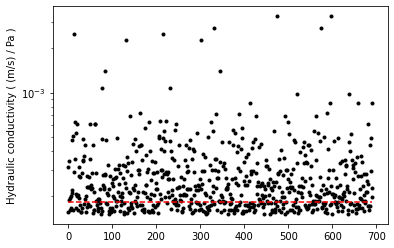

In [27]:
# Compute scaling that when multiplied with normalized conductivity goives (m/s) / Pa
edge_conductivity = RG.edge_conductivity_list()

plt.semilogy(edge_conductivity, 'k.')
plt.semilogy(np.arange(len(edge_conductivity)),
             RG.graph_conductivity()*np.ones_like(edge_conductivity), 'r--')
plt.ylabel("Hydraulic conductivity ( (m/s) / Pa )")
print("Conductivity of each edge (dot); full-graph network effective conductivity (dashed)")

#### $L_\mathrm{threshold} / \ell$  variation

In [43]:
# Placeholder input param
ensemble_size = 1600
N_chamber = 50
R_chamber = 500
x_scale = 40e3
z_scale = 40e3
sep_scale = np.sqrt(x_scale * z_scale) / (np.sqrt(N_chamber)-1)

a_ratios = np.linspace(0.5, 2.5, 12)
ensemble_graph_conductivity = [None for i in range(len(a_ratios))]

np.random.seed(1)

# Run ensemble
for i, a_ratio in enumerate(a_ratios):
  ensemble_graph_conductivity[i] = percolation_network.run_2D_ensemble(
    ensemble_size, N_chamber, x_scale, z_scale,
    a_ratio*sep_scale, R_chamber, R_chamber, processes=0)

# hist_n, hist_bins, hist_bars = plt.hist(ensemble_graph_conductivity, bins=100)

Probability of percolation


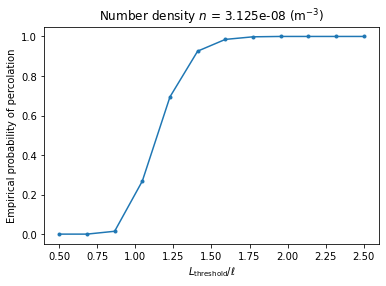

In [44]:
''' Continuum percolation data '''

# Reorganize the data into 2D array
cond_data = np.array(ensemble_graph_conductivity)
# Compute empirical probability of percolation
p_percolation = 1.0 - (0 == cond_data).astype(int).sum(axis=1) / cond_data.shape[1]

plt.plot(a_ratios, p_percolation, '.-')
plt.ylabel("Empirical probability of percolation")
plt.xlabel(r"$L_\mathrm{threshold} / \ell$")

n_density = (N_chamber / x_scale / z_scale)
plt.title(f"Number density $n$ = {n_density} " + r"(m${}^{-3}$)")
print("Probability of percolation")

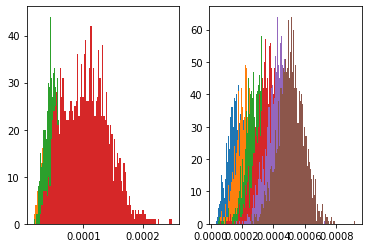

In [45]:
''' Binning ands plotting stacked histograms '''
plt.subplot(1,2,1)
hist_n = [[0] for i in range(cond_data.shape[0])]
hist_bins = [[0] for i in range(cond_data.shape[0])]

for i in range(0, cond_data.shape[0]//2):
  nonzero_data = cond_data[i,:][np.where(cond_data[i,:] > 0)]
  if len(nonzero_data) > 0:
    hist_n[i], hist_bins[i], bars = plt.hist(nonzero_data, bins=100)

plt.subplot(1,2,2)
for i in range(cond_data.shape[0]//2, cond_data.shape[0]):
  nonzero_data = cond_data[i,:][np.where(cond_data[i,:] > 0)]
  if len(nonzero_data) > 0:
    hist_n[i], hist_bins[i], bars = plt.hist(nonzero_data, bins=100)

pmf and Gamma fits for graph effective hydraulic conductivity normalized by dissipative factors (units 1/m)


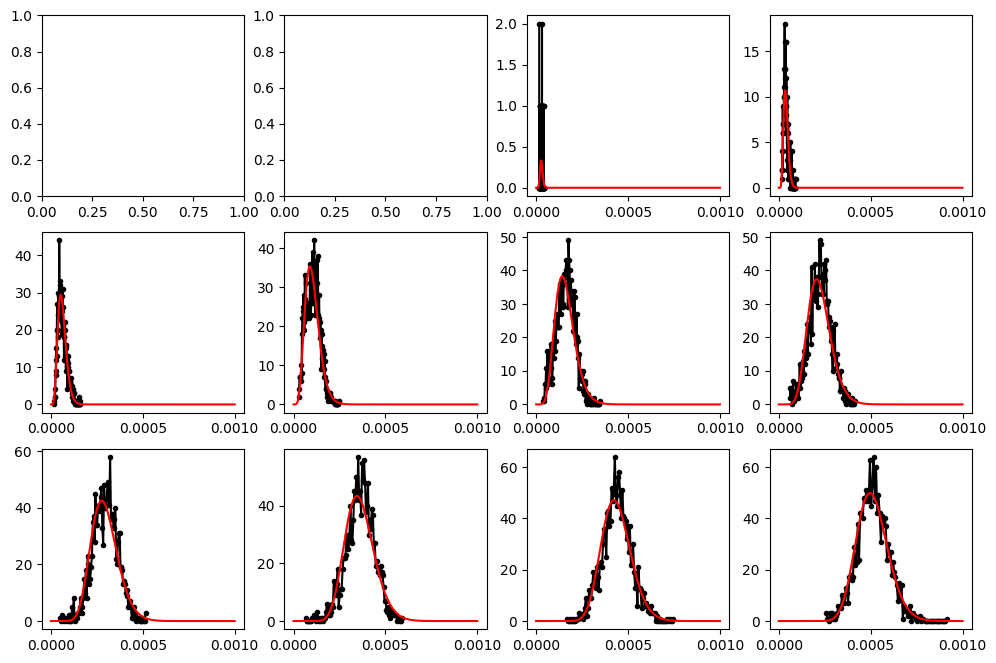

In [46]:
''' Gamma(a, scale) fits to pmf for each value of L_threshold / L_crust '''
fig =  plt.figure(figsize=(12,11), dpi=100)

# Allocate for gamma distribution fit parameters
param_a = np.nan * np.empty((cond_data.shape[0],))
param_loc = np.nan * np.empty((cond_data.shape[0],))
param_scale = np.nan * np.empty((cond_data.shape[0],))

# Plot up to 16 panels
for i in range(min(a_ratios.size, 16)):
  plt.subplot(4,4,i+1)
  # Extract nonzero data
  nonzero_data = cond_data[i,:][np.where(cond_data[i,:] > 0)]
  if nonzero_data.size > 0:
    # Compute histogram details
    bin_center = 0.5*(hist_bins[i][1:] + hist_bins[i][:-1])
    bin_size = (hist_bins[i][1:] - hist_bins[i][:-1])
    pmf_area = (hist_n[i] * bin_size).sum()
    # Plot histogram in panel
    plt.plot(0.5*(hist_bins[i][1:] + hist_bins[i][:-1]), hist_n[i], 'k.-')
    # Fit gamma distribution
    a, loc, scale = scipy.stats.gamma.fit(cond_data[i,:][np.where(cond_data[i,:] > 0)], scale=1e-5, floc=0)
    gammafit = scipy.stats.gamma(a, loc=loc, scale=scale)
    param_a[i], param_loc[i], param_scale[i] = a, loc, scale
    # Plot distribution
    plot_x_scale = np.linspace(0,0.001,500)
    plt.plot(plot_x_scale, gammafit.pdf(plot_x_scale) * pmf_area, 'r')

print("pmf and Gamma fits for graph effective hydraulic conductivity normalized by dissipative factors (units 1/m)")

#### $N_\mathrm{chamber}$  variation


In [122]:
# Placeholder input param
ensemble_size = 200 # 1600
R_chamber = 500
x_scale = 40e3
z_scale = 40e3

L_ratio = 1.4
N_chamber_range = np.linspace(4, 1600, 12).astype(int)
ensemble_graph_conductivity_N = [None for i in range(len(N_chamber_range))]

np.random.seed(2)

# Run ensemble
for i, N_chamber in enumerate(N_chamber_range):
  sep_scale = np.sqrt(x_scale * z_scale) / (np.sqrt(N_chamber)-1)
  ensemble_graph_conductivity_N[i] = percolation_network.run_2D_ensemble(
    ensemble_size, N_chamber, x_scale, z_scale,
    L_ratio*sep_scale, R_chamber, R_chamber, processes=0)

# hist_n, hist_bins, hist_bars = plt.hist(ensemble_graph_conductivity, bins=100)

Probability of percolation


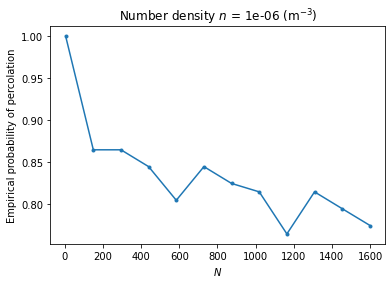

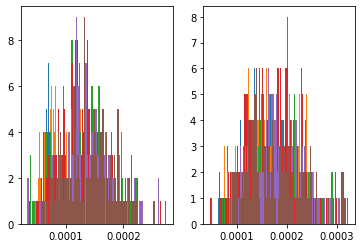

In [123]:
''' Binning and plotting stacked histograms '''
cond_data = np.array(ensemble_graph_conductivity_N)

# Compute empirical probability of percolation
p_percolation = 1.0 - (0 == cond_data).astype(int).sum(axis=1) / cond_data.shape[1]

plt.plot(N_chamber_range, p_percolation, '.-')
plt.ylabel("Empirical probability of percolation")
plt.xlabel(r"$N$")

n_density = (N_chamber / x_scale / z_scale)
plt.title(f"Number density $n$ = {n_density} " + r"(m${}^{-3}$)")
print("Probability of percolation")

plt.figure()

plt.subplot(1,2,1)
hist_n = [[0] for i in range(cond_data.shape[0])]
hist_bins = [[0] for i in range(cond_data.shape[0])]

for i in range(0, cond_data.shape[0]//2):
  nonzero_data = cond_data[i,:][np.where(cond_data[i,:] > 0)]
  if len(nonzero_data) > 0:
    hist_n[i], hist_bins[i], bars = plt.hist(nonzero_data, bins=100)

plt.subplot(1,2,2)
for i in range(cond_data.shape[0]//2, cond_data.shape[0]):
  nonzero_data = cond_data[i,:][np.where(cond_data[i,:] > 0)]
  if len(nonzero_data) > 0:
    hist_n[i], hist_bins[i], bars = plt.hist(nonzero_data, bins=100)

pmf and Gamma fits for graph effective hydraulic conductivity normalized by dissipative factors (units 1/m)


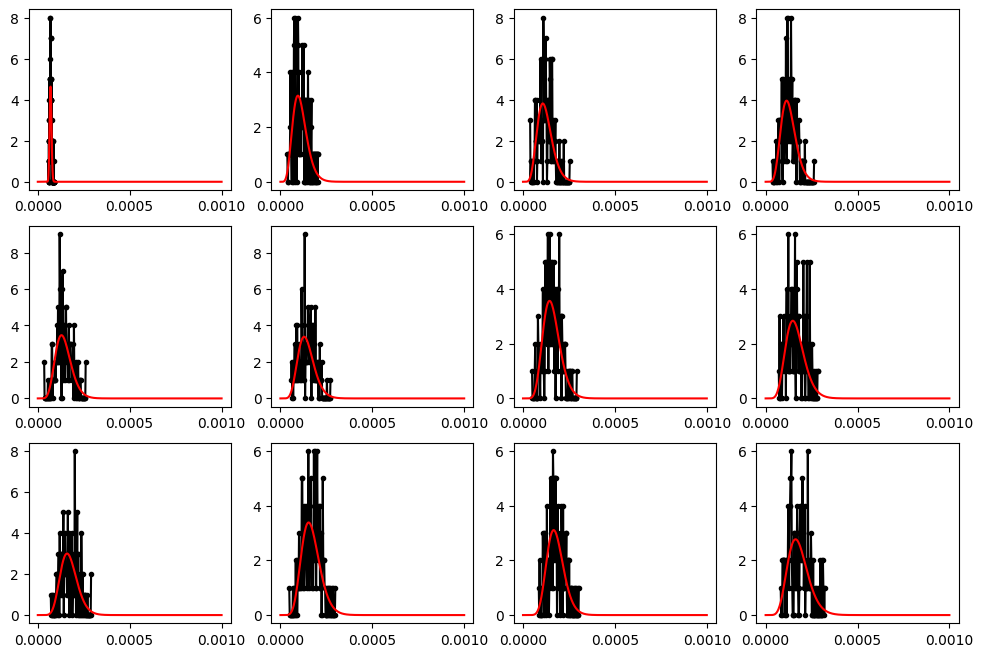

In [124]:
''' Gamma(a, scale) fits to pmf for each value of L_threshold / L_crust '''
fig =  plt.figure(figsize=(12,11), dpi=100)

# Allocate for gamma distribution fit parameters
param_a = np.nan * np.empty((cond_data.shape[0],))
param_loc = np.nan * np.empty((cond_data.shape[0],))
param_scale = np.nan * np.empty((cond_data.shape[0],))
fits = [None for i in range(cond_data.shape[0])]
# Plot up to 16 panels
for i in range(min(N_chamber_range.size, 16)):
  plt.subplot(4,4,i+1)
  # Extract nonzero data
  nonzero_data = cond_data[i,:][np.where(cond_data[i,:] > 0)]
  if nonzero_data.size > 0:
    # Compute histogram details
    bin_center = 0.5*(hist_bins[i][1:] + hist_bins[i][:-1])
    bin_size = (hist_bins[i][1:] - hist_bins[i][:-1])
    pmf_area = (hist_n[i] * bin_size).sum()
    # Plot histogram in panel
    plt.plot(0.5*(hist_bins[i][1:] + hist_bins[i][:-1]), hist_n[i], 'k.-')
    # Fit gamma distribution
    a, loc, scale = scipy.stats.gamma.fit(cond_data[i,:][np.where(cond_data[i,:] > 0)], scale=1e-5, floc=0)
    gammafit = scipy.stats.gamma(a, loc=loc, scale=scale)
    param_a[i], param_loc[i], param_scale[i] = a, loc, scale
    # Plot distribution
    plot_x_scale = np.linspace(0,0.001,500)
    plt.plot(plot_x_scale, gammafit.pdf(plot_x_scale) * pmf_area, 'r')
    fits[i] = gammafit

print("pmf and Gamma fits for graph effective hydraulic conductivity normalized by dissipative factors (units 1/m)")

In [ ]:
means = np.array([fit.mean() for fit in fits])
vars = np.array([fit.var() for fit in fits])

In [125]:
''' Equivalent lattice grid Fixed (N_x-1) / (N_z-1), varying N_z '''

N_grid_range = np.unique(np.sqrt(N_chamber_range).astype(int))
gc_range = np.zeros((len(N_grid_range),))
ec_range = np.zeros((len(N_grid_range),))

z_scale = 40e3
x_scale = 40e3
grid_L_ratio = 1.01

for i, N in enumerate(N_grid_range):
  N_z = N
  N_x = N

  # Set grid graph with lattice edges
  max_edge_dist = z_scale / (N_z-1) * grid_L_ratio
  RG = percolation_network.RandomGraph(
    percolation_network.make_2D_grid_network(N_x, N_z,
      x_scale=x_scale, z_scale=z_scale, R=500,
                          add_source_sink=False), max_edge_dist)
  gc_range[i] = RG.graph_conductivity()
  ec_range[i] = RG.edge_conductivity_list().max()


In [128]:
''' Continuum limit '''

def u_bdry(x, a):
  ''' u along boundary '''
  tm = np.abs(np.abs(x) - a)
  tp = np.abs(np.abs(x) + a)
  s1 = np.zeros_like(tm)
  np.log(tm, out=s1, where=tm>0)
  s1 = tm * (s1 - 1)
  s2 = tp * (np.log(tp) - 1)
  return -1.0/np.pi * np.where(np.abs(x) < a, s2 + s1, s2 - s1)

def SL_integral(x, z, z0, a):
  ''' Single-layer potential (integration from -a to a).
  Returns the solution u on the boundary when z = z0. '''
  dz = z - z0
  # Compute 1 / dz with no warnings
  dz_inv = np.zeros_like(dz)
  np.divide(1.0, dz, where=dz != 0, out=dz_inv)
  temp = (x - a) * np.log((x - a)*(x - a) + dz*dz) \
    - (x + a) * np.log((x + a)*(x + a) + dz*dz) \
    + 2 * dz * (np.arctan((x - a) * dz_inv) - np.arctan((x + a) * dz_inv)) + 4 * a
  # Use u bdry solution for limit dz = 0
  return np.where(dz != 0,  0.25 / np.pi * temp, 0.5 * u_bdry(x, a))

def U(x, z, num_images:int, a=1.0, L_z=10.0):
  u = np.zeros(x.shape)
  next_sign = 1.0
  for img_idx in range(num_images):
    u += 2.0 * next_sign * ( # Factor of 2 for SL - DL, where DL == -SL
      SL_integral(x, z, (-img_idx)*L_z, a)
      - SL_integral(x, z, (img_idx+1)*L_z, a))
    next_sign *= -1.0   
  return u

L_z = 40000
N_sample = 4
num_images = 100
lat_images = 100
eps = 0.0

V_range_min = np.zeros_like(N_range, dtype=float)
V_range_min_bounded = np.zeros_like(N_range, dtype=float)

for i, N in enumerate(N_grid_range):
  a = 0.5 * L_z / (N-1)

  x_vec_on_bdry = np.linspace(-a, a, N_sample)
  z_vec_on_bdry = eps * L_z * np.ones_like(x_vec_on_bdry)

  # Evaluate potential diff
  potential_diff = 2 * U(x_vec_on_bdry, z_vec_on_bdry, num_images, a=a, L_z=L_z)
  # Evaluate bounded version
  potential_diff_bounded = potential_diff.copy()
  for lat_idx in range(lat_images):
    potential_diff_bounded += 2 * (
      U(x_vec_on_bdry - 2 * L_z, z_vec_on_bdry, num_images, a, L_z)
      + U(x_vec_on_bdry + 2 * L_z, z_vec_on_bdry, num_images, a, L_z))

  V_range_min[i] = potential_diff.min()
  V_range_min_bounded[i] = potential_diff_bounded.min()

C:\Users\Fredric\AppData\Local\Temp\ipykernel_35404\909893426.py:18: RuntimeWarning: divide by zero encountered in log
  temp = (x - a) * np.log((x - a)*(x - a) + dz*dz) \
C:\Users\Fredric\AppData\Local\Temp\ipykernel_35404\909893426.py:18: RuntimeWarning: invalid value encountered in multiply
  temp = (x - a) * np.log((x - a)*(x - a) + dz*dz) \
C:\Users\Fredric\AppData\Local\Temp\ipykernel_35404\909893426.py:19: RuntimeWarning: divide by zero encountered in log
  - (x + a) * np.log((x + a)*(x + a) + dz*dz) \
C:\Users\Fredric\AppData\Local\Temp\ipykernel_35404\909893426.py:19: RuntimeWarning: invalid value encountered in multiply
  - (x + a) * np.log((x + a)*(x + a) + dz*dz) \


Error bars: empirical stdev of random graph
Normalized conductivity is mass flow rate divided by pressure difference, scaled down by density, viscosity and length scales


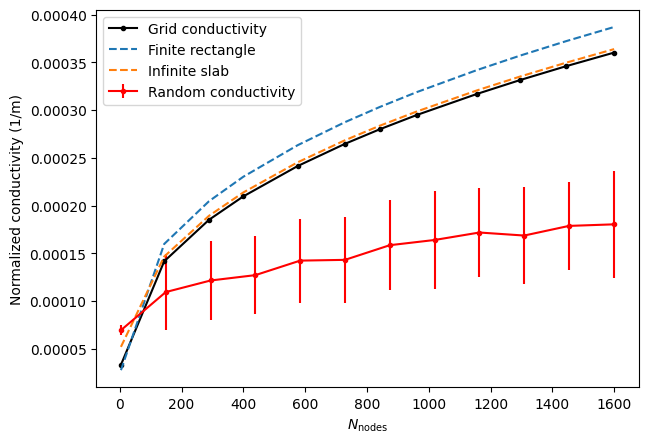

In [139]:
plt.figure(figsize=(7,5), dpi=100)
plt.errorbar(N_chamber_range, means, np.sqrt(vars), fmt="r.-",  label="Random conductivity")
plt.plot((N_grid_range)**2, gc_range, 'k.-', label="Grid conductivity")
plt.plot((N_grid_range)**2, 1/V_range_min_bounded, '--', label="Finite rectangle")
plt.plot((N_grid_range)**2, 1/V_range_min, '--', label="Infinite slab")

plt.legend()
plt.xlabel(r"$N_\mathrm{nodes}$")
plt.ylabel("Normalized conductivity (1/m)")
print("Error bars: empirical stdev of random graph")
print("Normalized conductivity is mass flow rate divided by pressure difference, scaled down by density, viscosity and length scales")

#### Unused

Lateral expansion (for evaluating finite width effect in graph problem)

In [ ]:
''' Lateral expansion '''
N_range = np.arange(9, 70, 10)
# N_range = np.array([23])
gc_range = np.zeros((len(N_range),))
ec_range = np.zeros((len(N_range),))

z_scale = 40e3

for i, N in enumerate(N_range):
  N_x = N
  N_z = 9
  x_scale = z_scale * (N_x-1) / (N_z-1)

  max_edge_dist = z_scale / (N_z-1) * 1.001
  RG = percolation_network.RandomGraph(
    percolation_network.make_2D_grid_network(N_x, N_z,
      x_scale=x_scale, z_scale=z_scale, R=500,
                          add_source_sink=False), max_edge_dist)
  gc_range[i] = RG.graph_conductivity()
  ec_range[i] = RG.edge_conductivity_list().max()

plt.subplot(1,2,1)
plt.plot(N_range, (N_range-1) / ec_range, '.')
plt.xlabel("$N$")
plt.ylabel("Edge conductivity * $(N-1)$")

plt.subplot(1,2,2)
plt.plot(N_range, gc_range, '.')
# plt.plot(N_range, gc_range / (N_range-1)**(1), '.')
plt.xlabel("$N$")
plt.ylabel("Graph conductivity, const current density")

plt.tight_layout()

#### Optimization

In [20]:
# TEMP: TODO:

def task():
  ''' Profiling task '''
  node_list = percolation_network.make_2D_grid_network(N_x, N_z, x_scale=x_scale, z_scale=z_scale,
                        R=500,
                        add_source_sink=False)
  
  max_edge_dist = z_scale / (N_z-1) * 1.01

  coords = np.array([[node.x, node.y, node.z] for node in node_list])
  # Compute distance into Y
  Y = scipy.spatial.distance.cdist(coords, coords)
  # Mask out edges based on threshold
  np.multiply(0.0, Y, where=Y > max_edge_dist, out=Y)
  # Compute 1/distance into Y where nonzero
  np.divide(1.0, Y, where=Y>0, out=Y)

  V = len(node_list)
  G = nx.Graph(Y)
  G = nx.Graph(scipy.sparse.coo_matrix(Y))
  L = nx.laplacian_matrix(G)

  # Manual L construction
  L = -Y
  L[np.arange(Y.shape[0]), np.arange(Y.shape[0])] += Y.sum(axis=1)
  L = scipy.sparse.coo_matrix(L)

  b = np.zeros((L.shape[0],))
  b[0] = 1.0
  b[-1] = -1.0
  v, exit_code = scipy.sparse.linalg.cg(L, b)

  return Y

Y = task()

%load_ext line_profiler
%lprun -f task task()

Timer unit: 1e-07 s

Total time: 1.31083 s
File: C:\Users\Fredric\AppData\Local\Temp\ipykernel_51980\3373018664.py
Function: task at line 3

Line #      Hits         Time  Per Hit   % Time  Line Contents
     3                                           def task():
     4                                             ''' Profiling task '''
     5         1     701412.0 701412.0      5.4    node_list = percolation_network.make_2D_grid_network(N_x, N_z, x_scale=x_scale, z_scale=z_scale,
     6         1          3.0      3.0      0.0                          R=500,
     7         1          3.0      3.0      0.0                          add_source_sink=False)
     8                                             
     9         1        278.0    278.0      0.0    max_edge_dist = z_scale / (N_z-1) * 1.01
    10                                           
    11         1      45377.0  45377.0      0.3    coords = np.array([[node.x, node.y, node.z] for node in node_list])
    12                  